In [4]:
pip install pandas

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.

   ---------------------------------------- 0.0/11.5 MB ? eta -:--:--
    --------------------------------------- 0.3/11.5 MB ? eta -:--:--
    --------------------------------------- 0.3/11.5 MB ? eta -:--:--
   -- ------------------------------------- 0.8/11.5 MB 1.1 MB/s eta 0:00:10
   --- ------------------------------------ 1.0/11.5 MB 1.3 MB/s eta 0:00:08
   ----- ---------------------------------- 1.6/11.5 MB 1.5 MB/s eta 0:00:07
   ------ --------------------------------- 1.8/11.5 MB 1.6 MB/s eta 0:00:06
   ------ --------------------------------- 1.8/11.5 MB 1.6 MB/s eta 0:00:06
   -------- ------------------------------- 2.4/11.5 MB 1.4 MB/s eta 0:00:07
   ---------- ----------------------------- 3.1/11.5 MB 1.7 MB/s eta 0:00:05
   ------------- -------------------------- 3.9/11.5 MB 1.9 MB/s eta 0:00:04
   ----------------- ---------

In [5]:
import pandas as pd

In [6]:
data = pd.read_csv("Data.csv")

In [7]:
data.head()

,Age,Bought Insurence
0,21,no
1,48,yes
2,32,yes
3,41,yes
4,20,no


In [8]:
import  matplotlib.pyplot as plt

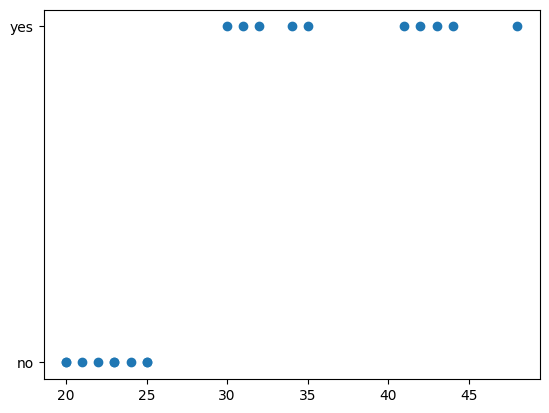

In [9]:
plt.scatter(data["Age"],data["Bought Insurence"])
plt.show()

In [10]:
data.replace(to_replace = ["yes", "no"] , value = [1, 0], inplace = True)

C:\Users\HP\AppData\Local\Temp\ipykernel_18716\3255586014.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data.replace(to_replace = ["yes", "no"] , value = [1, 0], inplace = True)


In [11]:
data.head()

,Age,Bought Insurence
0,21,0
1,48,1
2,32,1
3,41,1
4,20,0


In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19 entries, 0 to 18
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Age               19 non-null     int64
 1   Bought Insurence  19 non-null     int64
dtypes: int64(2)
memory usage: 436.0 bytes


In [13]:
data.describe()

,Age,Bought Insurence
count,19.000000,19.000000
mean,30.684211,0.526316
std,9.189684,0.512989
min,20.000000,0.000000
25%,23.000000,0.000000
50%,30.000000,1.000000
75%,38.000000,1.000000
max,48.000000,1.000000


In [16]:
pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


In [17]:
import seaborn as sns

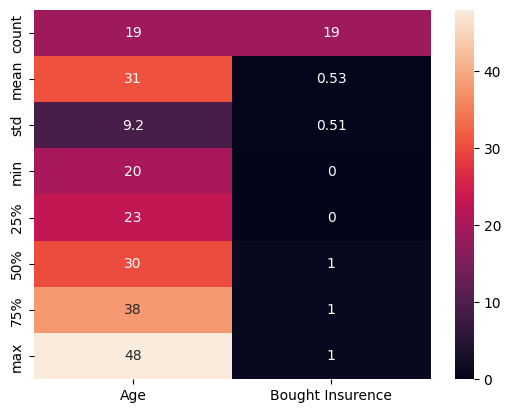

In [18]:
sns.heatmap(data.describe(), annot = True)
plt.show()

In [19]:
data.isnull().sum()

Age                 0
Bought Insurence    0
dtype: int64

In [20]:
data.corr()

,Age,Bought Insurence
Age,1.000000,0.862144
Bought Insurence,0.862144,1.000000


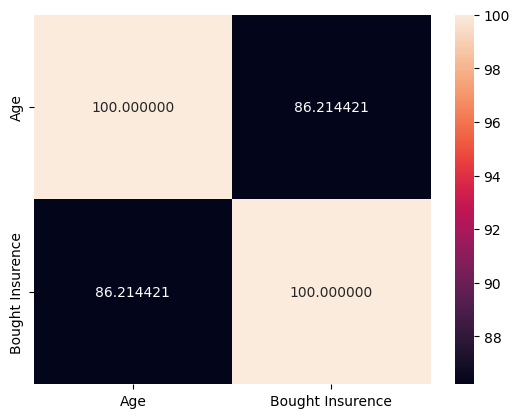

In [21]:
sns.heatmap(data.corr() * 100, annot = True, fmt = "2f")
plt.show()

In [22]:
from sklearn.model_selection import train_test_split

In [23]:
x = data.drop("Bought Insurence", axis = 1)
y = data["Bought Insurence"]

In [24]:
x_train, x_test, y_train , y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [25]:
x_train.shape

(15, 1)

In [26]:
y_train.shape

(15,)

In [27]:
from sklearn.linear_model import LogisticRegression

In [28]:
model = LogisticRegression()

In [29]:
model.fit(x_train, y_train)

LogisticRegression()

In [30]:
from sklearn.metrics import r2_score, accuracy_score, confusion_matrix, classification_report

In [31]:
y_pred = model.predict(x_test)

In [32]:
r2_score(y_test, y_pred) * 100

100.0

In [33]:
accuracy_score(y_test, y_pred)

1.0

In [34]:
evaluate = pd.DataFrame({

        "Actual Value" : y_test, 
        "Predicetd Value" : y_pred,
        "Error/Bias" : y_pred - y_test
})

In [35]:
evaluate

,Actual Value,Predicetd Value,Error/Bias
0,0,0,0
5,1,1,0
11,0,0,0
1,1,1,0


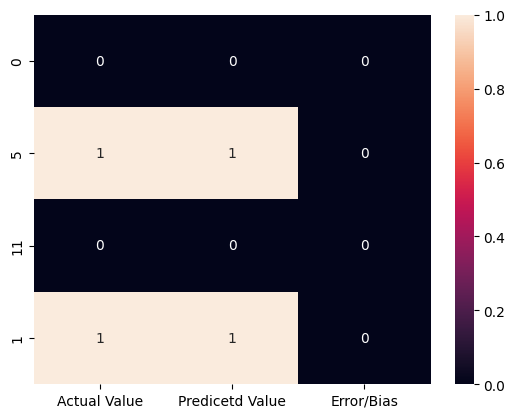

In [36]:
sns.heatmap(evaluate, annot = True)
plt.show()

In [37]:
conf_matrix = confusion_matrix(y_test, y_pred)

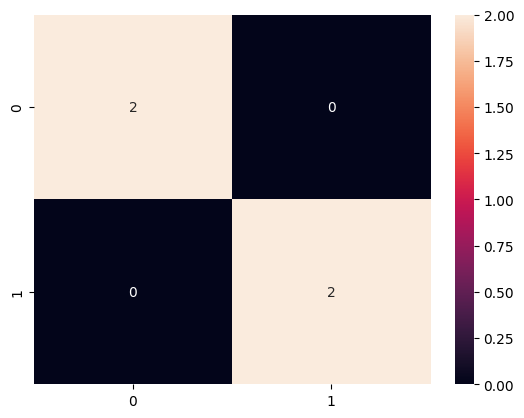

In [38]:
sns.heatmap(conf_matrix, annot = True)
plt.show()

In [39]:
report = classification_report(y_test, y_pred, output_dict = True)
new_report = pd.DataFrame(report).transpose()

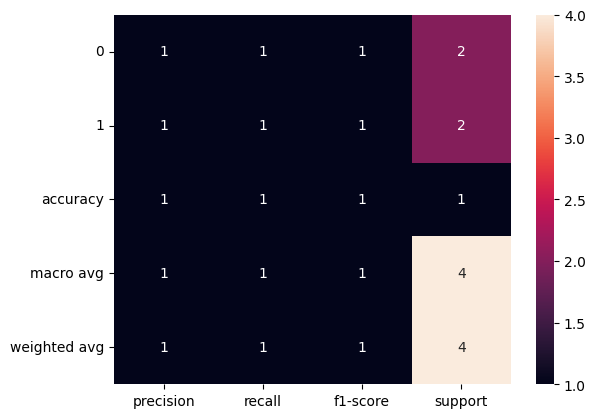

In [40]:
sns.heatmap(new_report, annot = True)
plt.show()

In [41]:
import joblib

In [42]:
joblib.dump(model, "Binary_model.joblib")

['Binary_model.joblib']